## RL Book Graphics 1

- Alright diving in here to get these book graphics done!
- This is going to be more of a slog since we didn't complete the video
- Will turn parts of these notebooks into supporting code
- Need to look at that scaling issue that I glossed over last time
- I really want to show the math and details when going to trajectories, and gradient of trajectories, we glossed over these last time too
- Alright here we go.
- First we need to show the game and some gameplay
- I'm seeing showing rollouts first and maybe for a while as tiny little carts arranged vertically so you can see the left right movement
- Paired with this i want to show the action at each step, and a vertical line plot of our varialbes, then the state space view at the bottom? Will take some noodling. Could also superimpose the x time series on top of the vertical carts
- I'm also tempted to actually do the full supporting code first, that way I would know that the the examples and scaling I'm doing will get me where I need to go. Hmmm. I do think we'll want to do some version of that. Let me hack on the first couple figures here first, but yeah I think I'll probably want to get the code through the end done before I do like training animations - I know these are sensitive to scaling etc, the divide by 10 thing I did etc...
- Also some bleeds could be fun, but kinda thinking light mode? Let's see how it goes here...
- Hmm yeah data scaling even kinda comes up in the first figure I guess...
- Ok I noodled with scaling a bit again, I do think that converting angles to degrees and dividing velocities by 10 is the way to go
- Yes it's like extra preprocessing, and velocity unites are now degrees/s /10 or degrees per decisecond or something, that's annoying, but I don't want to like normalize these variable. And the radian/degree thing is a separate issue, we would have this problem either way!
- Hmm would a table to numeric values also be nice/interesting for some of the early visuals to give more of a sense of the data. 

In [30]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"
FRESH_TAN='#d0c3ad'

kt_orange='#eb8423'
kt_lt_blue='#5badb6'
kt_dk_blue='#063336'

In [31]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [32]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [33]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/'
SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics'

In [58]:
# #Export reduced version for repo!
# with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
#     data = json.load(f)

# import copy
# data_trimmed = copy.deepcopy(data)
# data_trimmed['episodes'] = [data['episodes'][13]]

# with open(HACKIN_DIR+"/cartpole_human_play/sw_cartpole_game.json", 'w') as f:
#     json.dump(data_trimmed, f)

# with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 
    
# data_trimmed = copy.deepcopy(data)
# data_trimmed['episodes'] = [data['episodes'][55]]

# with open(HACKIN_DIR+"/cartpole_human_play/champion_cartpole_game.json", 'w') as f:
#     json.dump(data_trimmed, f)

In [34]:
with open(HACKIN_DIR+"/cartpole_human_play/cartpole_human_demos_sw_3.json") as f: #This one has some pretty good runs from SW
    data = json.load(f)

# with open(HACKIN_DIR/"cartpole_human_play/cartpole_human_demos_pranav_4.json") as f: 
#     data = json.load(f) 

VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space
for ep in data["episodes"]:
    o = np.array(ep["observations"], dtype=np.float64)
    o[:, 1] /= VEL_SCALE   # cart velocity
    o[:, 3] /= VEL_SCALE   # pole angular velocity
    ep["observations"] = o

print(len(data["episodes"]))

18


In [35]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.09
X_LIM = (-2.4, 2.4)

def draw_cartpole(ax, cart_x, pole_theta, action=None, y0=0.0,
                  setup_axes=True, track=True, arrow_size=420, arrow_dy=-0.32, stroke_color='k', fill_color='w'):
    """Draw one cart-pole state with its track baseline at y=y0."""
    if setup_axes:
        ax.set_xlim(*X_LIM); ax.set_ylim(y0-0.55, y0+1.75)
        ax.set_aspect('equal'); ax.axis('off')
    if track:
        ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)
    cart_y = y0 + WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R, color=stroke_color, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc=fill_color, ec=stroke_color, lw=2.0, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color=stroke_color, lw=3, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.07, color=stroke_color, zorder=6))
    if action is not None:   # needs RIGHT_ARROW / LEFT_ARROW defined
        ax.scatter([cart_x], [y0+arrow_dy],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=arrow_size,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)


def episode_frame_indices(n_steps, n_plots):
    """Evenly spaced step indices, always including the first and last step."""
    return np.unique(np.round(np.linspace(0, n_steps-1, n_plots)).astype(int))


def draw_episode(cart_xs, pole_thetas, n_plots, actions=None, spacing=1.6,
                 ax=None, fig_width=3.0, show_actions=False, label_steps=False,
                 pad_top=1.75, pad_bottom=0.55, top_down=True, **cartpole_kwargs):
    """
    Stack n_plots cart-pole states vertically in a single axis.

    spacing   : vertical distance between track baselines, in data units
                (the cart+pole is ~1.4 tall, so spacing < 1.4 will overlap).
    top_down  : first step at the top (True) or bottom (False).
    Returns fig, ax, idx (the step indices drawn), ys (baseline y of each frame).
    """
    cart_xs, pole_thetas = np.asarray(cart_xs), np.asarray(pole_thetas)
    idx = episode_frame_indices(len(cart_xs), n_plots)
    ys = -spacing*np.arange(len(idx)) if top_down else spacing*np.arange(len(idx))

    if ax is None:
        x_range = X_LIM[1]-X_LIM[0]
        y_range = spacing*(len(idx)-1) + pad_top + pad_bottom
        fig = plt.figure(figsize=(fig_width, fig_width*y_range/x_range))
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    for t, y0 in zip(idx, ys):
        a = actions[t] if (show_actions and actions is not None) else None
        draw_cartpole(ax, cart_xs[t], pole_thetas[t], action=a, y0=y0,
                      setup_axes=False, **cartpole_kwargs)
        if label_steps:
            ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom',
                    color=CHILL_BROWN, fontsize=8)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(ys.min()-pad_bottom, ys.max()+pad_top)
    ax.set_aspect('equal'); ax.axis('off')
    return fig, ax, idx, ys

In [36]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

def draw_actions(acts, n_plots, spacing=1.6, arrow_colors=None, ax=None,
                 fig_width=3.0, arrow_size=420, arrow_x=0.0, arrow_dy=0.0,
                 pad_top=1.75, pad_bottom=0.55, top_down=True, save=None):
    """
    Left/right push arrows stacked vertically, sampled at the same step indices
    and y positions as draw_episode, so the two figures overlay cleanly.

    arrow_colors : (left_color, right_color); defaults to (kt_lt_blue, kt_orange)
    arrow_dy     : vertical offset of the arrow from each frame's track baseline
    save         : optional path; saves an SVG with a transparent background
    Returns fig, ax, idx, ys
    """
    left_c, right_c = arrow_colors or (kt_lt_blue, kt_orange)
    acts = np.asarray(acts)
    idx = episode_frame_indices(len(acts), n_plots)
    ys = -spacing*np.arange(len(idx)) if top_down else spacing*np.arange(len(idx))

    if ax is None:
        x_range = X_LIM[1]-X_LIM[0]
        y_range = spacing*(len(idx)-1) + pad_top + pad_bottom
        fig = plt.figure(figsize=(fig_width, fig_width*y_range/x_range))
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    a = acts[idx]
    y = ys + arrow_dy
    ax.scatter(np.full((a==1).sum(), arrow_x), y[a==1], marker=RIGHT_ARROW,
               s=arrow_size, color=right_c, linewidths=0)
    ax.scatter(np.full((a==0).sum(), arrow_x), y[a==0], marker=LEFT_ARROW,
               s=arrow_size, color=left_c, linewidths=0)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(ys.min()-pad_bottom, ys.max()+pad_top)
    ax.set_aspect('equal'); ax.axis('off')
    if save:
        fig.savefig(SAVE_DIR+save, format='svg', transparent=True, bbox_inches=None)
    return fig, ax, idx, ys

In [37]:
# t=11
# fig=plt.figure(0, (3,3))
# ax=fig.add_subplot(111)
# draw_cartpole(ax, obs[t,0], obs[t,2], action=act[t])

In [38]:
all_obs=[]
all_actions=[]
episode_ids=[]

num_training_episodes=1
min_episode_len=30
episode_id=0

for i in [13]: #pick manually, 0, 13 from cartpole_human_demos_sw_3 gets middling but not collapsed determnistic performance!
    ep=data["episodes"][i]
    all_obs.append(ep["observations"])
    all_actions.append(ep["actions"])
    episode_ids.append(np.ones(len(ep["actions"]))*episode_id)
    episode_id+=1
    print(i, len(ep['observations']))

obs=np.concatenate(all_obs)
act=np.concatenate(all_actions)
ep_ids=np.concatenate(episode_ids)

13 66


In [10]:
ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])

In [16]:
###Visualize Cart
# fig, ax, idx, ys=draw_episode(obs[:,0], obs[:, 2], 23, spacing=2.0, 
#                               stroke_color=FRESH_TAN, fill_color=kt_dk_blue, track=True)
# fig, ax, idx, ys=draw_episode(obs[:,0], obs[:, 2], 26, spacing=2.0, 
#                               stroke_color='k', fill_color='w', track=True)
# plt.savefig(SAVE_DIR+'/carts_6.svg')

In [12]:
### Visualize matching arrows
# fig2, *_ = draw_actions(act, n_plots=23, spacing=1.0, save='/action_arrows_5.svg');

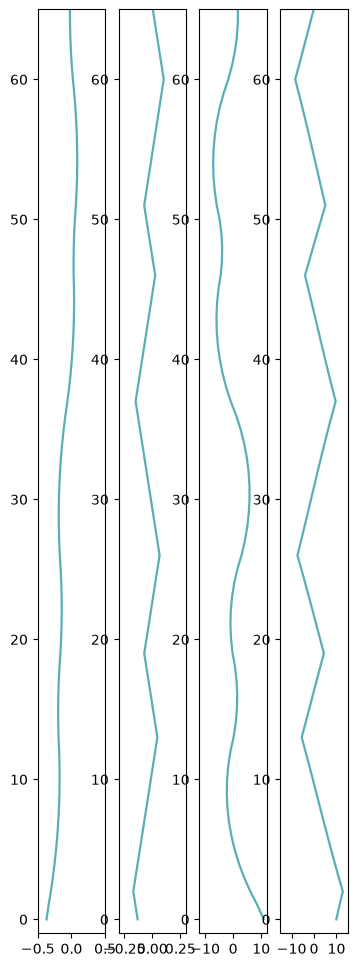

In [13]:
lw=1.6

fig=plt.figure(0, (4, 12))
fig.add_subplot(1,4,1)
plt.plot(obs[::-1,0], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-0.5, 0.5]); plt.ylim([-1, len(obs)-1])

fig.add_subplot(1,4,2)
plt.plot(obs[::-1,1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-0.3, 0.3]); plt.ylim([-1, len(obs)-1])

fig.add_subplot(1,4,3)
plt.plot(ang[::-1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-12,12]); plt.ylim([-1, len(obs)-1])

fig.add_subplot(1,4,4)
plt.plot(angvel[::-1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-15,15]); plt.ylim([-1, len(obs)-1])

plt.savefig(SAVE_DIR+'/time_series_1.svg')

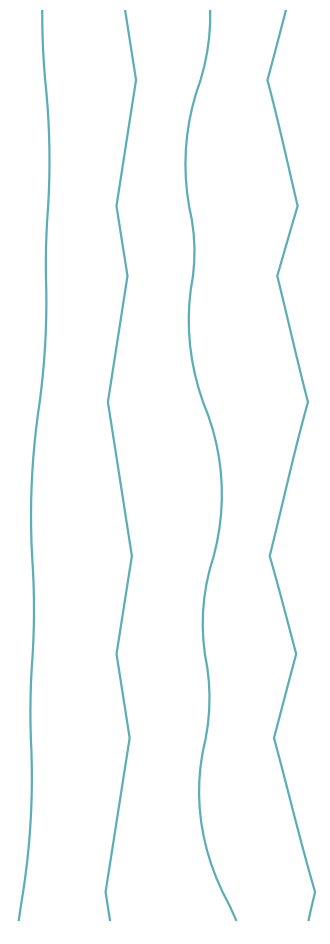

In [14]:
lw=1.6

fig=plt.figure(0, (4, 12))
fig.add_subplot(1,4,1)
plt.plot(obs[::-1,0], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-0.5, 0.5]); plt.ylim([-1, len(obs)-1])
plt.axis('off')

fig.add_subplot(1,4,2)
plt.plot(obs[::-1,1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-0.3, 0.3]); plt.ylim([-1, len(obs)-1])
plt.axis('off')

fig.add_subplot(1,4,3)
plt.plot(ang[::-1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-12,12]); plt.ylim([-1, len(obs)-1])
plt.axis('off')

fig.add_subplot(1,4,4)
plt.plot(angvel[::-1], range(len(obs)), c=kt_lt_blue, lw=lw); #plt.grid(1)
plt.xlim([-15,15]); plt.ylim([-1, len(obs)-1])
plt.axis('off')

plt.savefig(SAVE_DIR+'/time_series_2.svg')

### Ok dope, now state space with arrows!

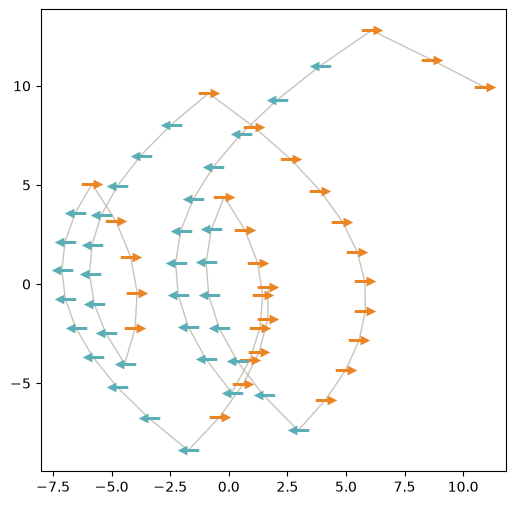

In [29]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)

ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])
m = act == 1
plt.plot(ang, angvel, color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
step_scatter_r=ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=240, color=kt_orange, alpha=1.0, linewidths=0)
step_scatter_l=ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=240, color=kt_lt_blue,   alpha=1.0, linewidths=0)

# plt.grid(1)

<Figure size 640x480 with 0 Axes>

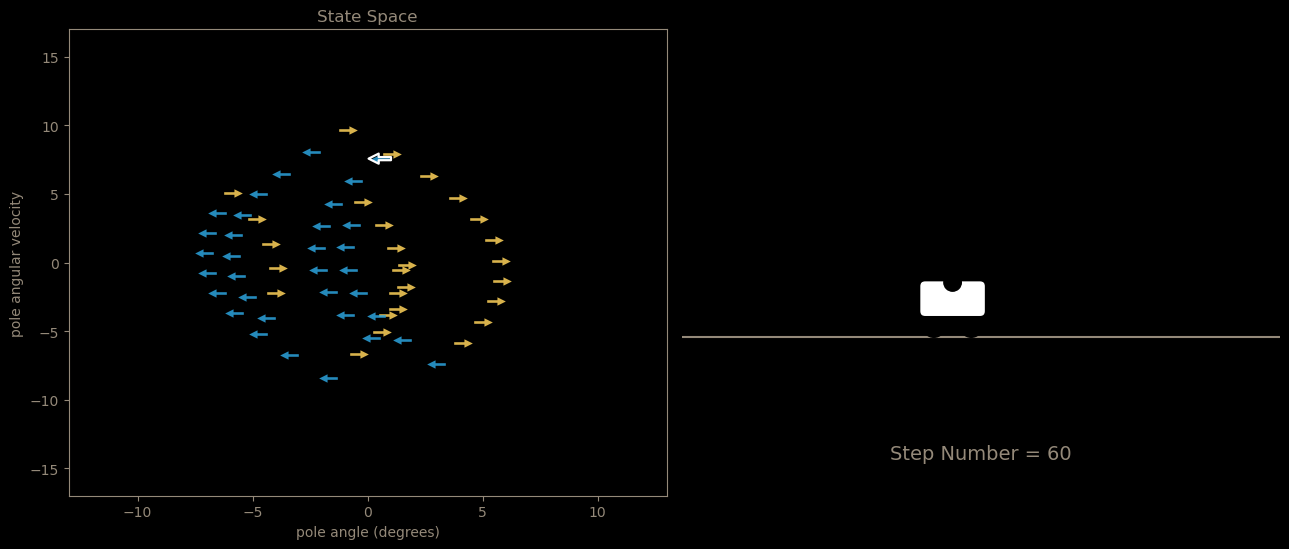

In [179]:
t=60
plt.clf()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])
m = act[:t+1] == 1
a, v = ang[:t+1], angvel[:t+1]
step_scatter_r=axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
step_scatter_l=axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

is_terminal = (t == len(act)-1)
axL.scatter([ang[t]], [angvel[t]],
            marker=(RIGHT_ARROW if act[t]==1 else LEFT_ARROW), s=260,
            facecolors='none', edgecolors=(RED if is_terminal else 'w'),
            linewidths=1.6, zorder=5)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity') # (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)

draw_cartpole(axR, obs[t,0], obs[t,2], action=act[t])
axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
         ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()
# if save:
#     plt.savefig(save, dpi=140, facecolor='k'); plt.close(fig)
# step_scatter_r.set_alpha(0.3)
# step_scatter_l.set_alpha(0.3)

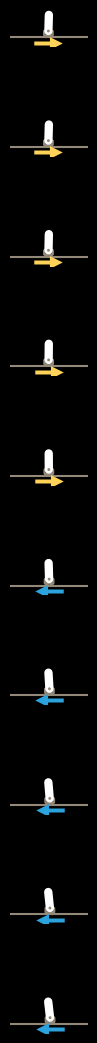

In [22]:
fig=plt.figure(0, (1, 14), facecolor='k')
for i in range(10):
    ax=fig.add_subplot(10, 1, i+1, facecolor='k')
    draw_cartpole(ax, obs[i,0], obs[i,2], action=act[i])

<Figure size 640x480 with 0 Axes>

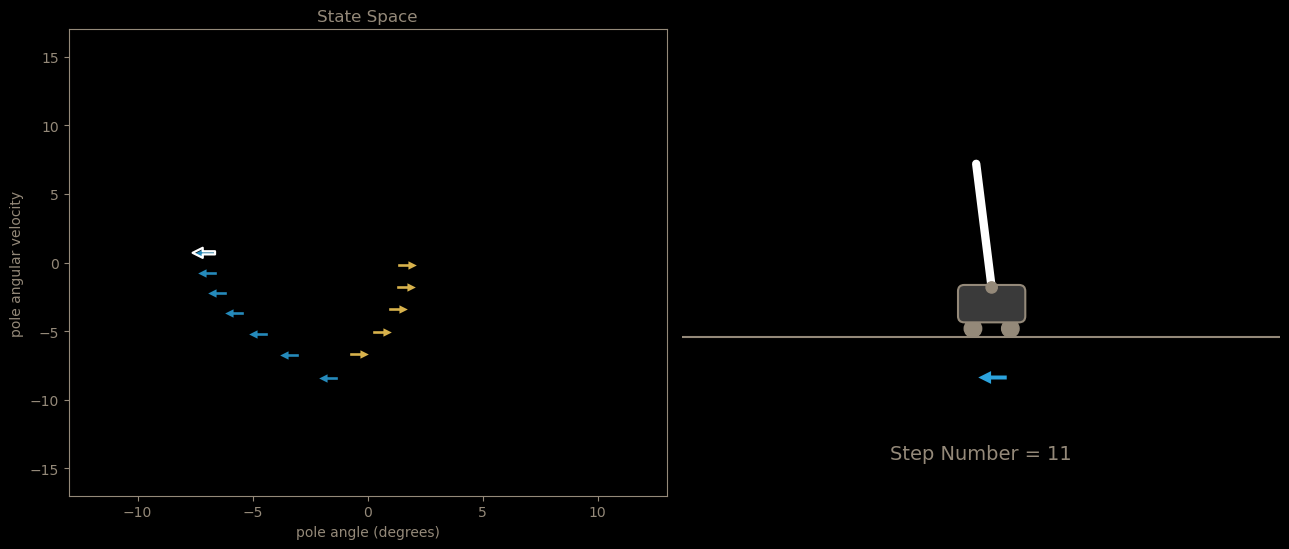

In [15]:
t=11
plt.clf()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

ang    = np.degrees(obs[:, 2])
angvel = np.degrees(obs[:, 3])
m = act[:t+1] == 1
a, v = ang[:t+1], angvel[:t+1]
step_scatter_r=axL.scatter(a[m],  v[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0)
step_scatter_l=axL.scatter(a[~m], v[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0)

is_terminal = (t == len(act)-1)
axL.scatter([ang[t]], [angvel[t]],
            marker=(RIGHT_ARROW if act[t]==1 else LEFT_ARROW), s=260,
            facecolors='none', edgecolors=(RED if is_terminal else 'w'),
            linewidths=1.6, zorder=5)

axL.set_xlim(*ANG_LIM); axL.set_ylim(*VEL_LIM)
axL.set_xlabel('pole angle (degrees)'); axL.set_ylabel('pole angular velocity') # (degrees/s \u00f7 10)')
axL.set_title('State Space'); style_ax(axL)

draw_cartpole(axR, obs[t,0], obs[t,2], action=act[t])
axR.text(0.5, -0.2, f'Step Number = {t}', transform=axR.transAxes,
         ha='center', va='bottom', color=CHILL_BROWN, fontsize=14)
plt.tight_layout()
# if save:
#     plt.savefig(save, dpi=140, facecolor='k'); plt.close(fig)
# step_scatter_r.set_alpha(0.3)
# step_scatter_l.set_alpha(0.3)